In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader

from sklearn.utils.class_weight import compute_class_weight

from collections import Counter
import re
import pandas as pd
from helper_utils import *

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import torch

# Dynamically target NVIDIA GPU, Apple Silicon GPU, or fallback to CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() 
    else "cpu"
)
print(f"Using device: {device}")

Using device: cuda


In [4]:
df = pd.read_csv('data/recipes_fruit_veg.csv')

In [5]:
df.head()

,name,id,minutes,ingredients,steps,category
0,a bit different breakfast pizza,31490,30,"['prepared pizza crust', 'sausage patty', 'egg...","['preheat oven to 425 degrees f', 'press dough...",vegetable
1,all in the kitchen chili,112140,130,"['ground beef', 'yellow onions', 'diced tomato...","['brown ground beef in large pot', 'add choppe...",vegetable
2,alouette potatoes,59389,45,"['spreadable cheese with garlic and herbs', 'n...",['place potatoes in a large pot of lightly sal...,vegetable
3,apple a day milk shake,5289,0,"['milk', 'vanilla ice cream', 'frozen apple ju...","['combine ingredients in blender', 'cover and ...",fruit
4,bananas 4 ice cream pie,70971,180,"['chocolate sandwich style cookies', 'chocolat...","['crumble cookies into a 9-inch pie plate , or...",fruit


In [6]:
df.shape

(142915, 6)

In [7]:
df.category.value_counts()

category
vegetable    113767
fruit         29148
Name: count, dtype: int64

In [8]:
# new column

df['label'] = 1

In [9]:
df.loc[df['category'] == 'fruit','label'] = 0

In [10]:
# names of recipes

texts = df['name'].to_list()

labels = df['label'].to_list()

In [11]:
texts

['a bit different  breakfast pizza',
 'all in the kitchen  chili',
 'alouette  potatoes',
 'apple a day  milk shake',
 'bananas 4 ice cream  pie',
 'beat this  banana bread',
 'berry  good sandwich spread',
 'better than sex  strawberries',
 'better then bush s  baked beans',
 'chicken lickin  good  pork chops',
 'chile rellenos',
 'chinese  candy',
 'chinese  chop suey',
 'cream  of cauliflower soup  vegan',
 'cream  of spinach soup',
 'crispy crunchy  chicken',
 'emotional balance  spice mixture',
 'fool the meat eaters  chili',
 'forgotten  minestrone',
 'fried  potatoes',
 'george s at the cove  black bean soup',
 'get the sensation  brownies',
 'global gourmet  taco casserole',
 'grilled  venison burgers',
 'homemade  vegetable soup from a can',
 'how i got my family to eat spinach  spinach casserole',
 'i can t believe it s low fat  creamy potato salad',
 'i can t believe it s spinach',
 'i don t feel like cooking tonight  casserole',
 'i stole the idea from mirj  sesame noodles'

In [12]:
len(texts) , len(labels)

(142915, 142915)

In [13]:
display(df[['name','label']].sample(5,random_state=25).style.hide(axis='index'))

name,label
cajun tomato gravy,1
scallop soup,1
chicken piccata light,0
bombay kidney beans,1
surefire siu mai dim sum,1


In [14]:
from sklearn.model_selection import train_test_split

In [15]:
train_texts , val_texts , train_labels , val_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,
    stratify=labels 
)

In [16]:
len(train_texts),len(train_labels)

(114332, 114332)

In [17]:
len(val_texts),len(val_labels)

(28583, 28583)

In [18]:
def preprocss_text(text):
    text = text.lower()
    text = re.sub(r'[^1-zA-Z\s]',"",text)
    words = text.split()
    return words

In [19]:
dic = {'<pad>':0,'<unk>':1}
{j:i for i,j in dic.items()}

{0: '<pad>', 1: '<unk>'}

In [20]:
processed_train_texts = [preprocss_text(i) for i in train_texts]
processed_val_texts = [preprocss_text(i) for i in val_texts]

In [21]:
class Vocabulary:
    def __init__(self,min_freq=1):

        self.word2idx = {'<pad>':0,'<unk>':1}
        self.idx2word = {0: '<pad>', 1: '<unk>'}
        self.min_freq = min_freq

    def build_vocab(self,texts):
        word_counts = Counter(word for text in texts for word in text)
        
        for word,count in word_counts.items():
            if count >= self.min_freq:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word
    def show_vocab(self):
        return self.word2idx
                
    def encode(self,text):
        return [self.word2idx.get(word,self.word2idx['<unk>']) for word in text]

    def decode(self,list_numbers):
        return [self.idx2word.get(i,self.word2idx['<unk>']) for i in list_numbers]

    def __len__(self):
        return len(self.word2idx)

In [22]:
vocab = Vocabulary(min_freq=1)

In [23]:
vocab.build_vocab(processed_train_texts)

In [24]:
# Encoding

indexed_train_texts = [vocab.encode(i) for i in processed_train_texts]
indexed_val_texts = [vocab.encode(i) for i in processed_val_texts]

In [25]:
indexed_train_texts[:5]

[[2, 3, 4],
 [5, 6],
 [7, 8, 9, 10, 11, 12],
 [13, 14, 15, 16, 17, 15, 18],
 [6, 19, 20, 21, 22]]

In [26]:
# Preparing data for training

In [27]:
class TextDataset(Dataset):

    def __init__(self,texts,labels):

        self.texts = texts
        self.labels = labels

        self.classes = sorted(list(set(labels)))

    def __len__(self):
        return len(self.texts)

    def __getitem__(self,idx):

        sample = {
            "text": torch.tensor(self.texts[idx],dtype=torch.long),
            "label":torch.tensor(self.labels[idx],dtype=torch.long)
        }
        return sample

In [28]:
train_dataset = TextDataset(indexed_train_texts,train_labels)
val_dataset = TextDataset(indexed_val_texts,val_labels)

In [29]:
len(train_dataset) , len(val_dataset)

(114332, 28583)

In [30]:
[0] + [len(i) for i in "apple a day  milk shake".split()]

[0, 5, 1, 3, 4, 5]

In [31]:
def collate_batch_embeddingbag(batch):

    labels = torch.tensor([item['label'] for item in batch])

    texts = [item['text'] for item in batch]
    
    offset = [0] + [len(i) for i in texts]
    
    offset = torch.tensor(offset[:-1]).cumsum(dim=0)

    flattenend_text = torch.cat(texts)

    return flattenend_text.to(device) , offset.to(device) , labels.to(device)

In [32]:
def collate_batch_manual(batch):

    labels = torch.tensor([item['label'] for item in batch])

    texts = [item['text'] for item in batch]
    

    max_len = max(len(text) for text in texts)

    padded_texts = torch.zeros(len(texts),max_len,dtype=torch.long)

    
    for i , text in enumerate(texts):
        padded_texts[i,:len(text)] = text

    return padded_texts.to(device) , labels.to(device)

In [33]:
batch_size = 32


train_loader_embag = DataLoader(train_dataset,
                               batch_size=batch_size,
                               shuffle=True,
                               collate_fn=collate_batch_embeddingbag)

val_loader_embag = DataLoader(val_dataset,
                               batch_size=batch_size,
                               shuffle=False,
                               collate_fn=collate_batch_embeddingbag)

In [34]:
tranin_loader_manual = DataLoader(train_dataset,
                               batch_size=batch_size,
                               shuffle=True,
                               collate_fn=collate_batch_manual)

val_loader_manual = DataLoader(val_dataset,
                               batch_size=batch_size,
                               shuffle=False,
                               collate_fn=collate_batch_manual)

### Model Buliding
**1. EmbeddingBagClassifier**

In [35]:
class EmbeddingBagClassifier(nn.Module):

    def __init__(self,vocab_size,embedding_dim,num_classes):
        super().__init__()
        self.embedding_bag = nn.EmbeddingBag(vocab_size,embedding_dim,mode='mean')
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(embedding_dim,num_classes)

    def forward(self,text,offsets=None):
        embedded = self.embedding_bag(text,offsets)
        embedded = self.dropout(embedded)

        return self.fc(embedded)

**2. ManualPooling Classifier**

In [36]:
class ManualPoolingCLassifier(nn.Module):

    def __init__(self,vocab_size,embedding_dim,num_classes,pooling='mean'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size,embedding_dim,padding_idx=0)
        self.pooling = pooling
        self.fc = nn.Linear(embedding_dim,num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self,text,offsets=None):
        embedded = self.embedding(text)
        mask = (text != 0).float().unsqueeze(-1)
        embedded = embedded * mask

        # mean :- prevents division by zero for empty sequence
        if self.pooling == "mean":
            pooled = embedded.sum(dim=1)/ mask.sum(dim=1).clamp(min=1)

        # max :- set padded postions to negative infinity so we will use max() which can ignored
        elif self.pooling == "max":
            embedded[mask.squeeze(-1) == 0] = float('-inf')
            pooled , _ = embedded.max(dim=1)
        
        # sum :- Sum the embedding of all non-padded tokens
        elif self.pooling == "sum":
            pooled = embedded.sum(dim=1)

        # Apply dropout and the final linear layer
        pooled = self.dropout(pooled)
        return self.fc(pooled)

In [37]:
# Define Model Parameters

vocab_size = len(vocab)
embedding_dim = 64
num_classes = 2

##### EmbeddingBag Model

In [38]:
model_embag = EmbeddingBagClassifier(vocab_size,embedding_dim,num_classes)

##### ManualPooling Models

In [39]:
# mean
model_manual_mean = ManualPoolingCLassifier(vocab_size,embedding_dim,num_classes,pooling='mean')
# max
model_manual_max = ManualPoolingCLassifier(vocab_size,embedding_dim,num_classes,pooling='max')
# sum
model_manual_sum = ManualPoolingCLassifier(vocab_size,embedding_dim,num_classes,pooling='sum')

In [40]:
train_label_list = train_labels

In [41]:
# automatically calulate weight

class_weight = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_label_list),
    y=train_label_list
)

In [42]:
class_weight = torch.tensor(class_weight,dtype=torch.float).to(device)

In [43]:
print(f"Fruit      Class 0 :- {class_weight[0].item():.2f}")
print(f"Vegetables Class 1 :- {class_weight[1].item():.2f}")

Fruit      Class 0 :- 2.45
Vegetables Class 1 :- 0.63


##### Loss function

In [44]:
loss_function = nn.CrossEntropyLoss(weight=class_weight)

In [45]:
num_epoch = 10

In [46]:
trained_embag  , results_embag = training_loop(
    model_embag,
    train_loader_embag,
    val_loader_embag,
    loss_function,
    num_epoch,
    device
)

--- Training for EmbeddingBagClassifier ---
Epoch [1/10], Train Loss: 0.3646, Val Loss: 0.2151, Val Accuracy: 0.9232
Epoch [2/10], Train Loss: 0.2307, Val Loss: 0.1882, Val Accuracy: 0.9311
Epoch [3/10], Train Loss: 0.1992, Val Loss: 0.1789, Val Accuracy: 0.9369
Epoch [4/10], Train Loss: 0.1824, Val Loss: 0.1741, Val Accuracy: 0.9374
Epoch [5/10], Train Loss: 0.1726, Val Loss: 0.1715, Val Accuracy: 0.9380
Epoch [6/10], Train Loss: 0.1658, Val Loss: 0.1699, Val Accuracy: 0.9385
Epoch [7/10], Train Loss: 0.1593, Val Loss: 0.1709, Val Accuracy: 0.9406
Epoch [8/10], Train Loss: 0.1556, Val Loss: 0.1688, Val Accuracy: 0.9397
Epoch [9/10], Train Loss: 0.1525, Val Loss: 0.1690, Val Accuracy: 0.9428
Epoch [10/10], Train Loss: 0.1504, Val Loss: 0.1701, Val Accuracy: 0.9411
--- Training completed ---


In [47]:
trained_mean  , results_mean = training_loop(
    model_manual_mean,
    tranin_loader_manual,
    val_loader_manual,
    loss_function,
    num_epoch,
    device
)

--- Training for ManualPoolingCLassifier ---
Epoch [1/10], Train Loss: 0.3706, Val Loss: 0.2162, Val Accuracy: 0.9212
Epoch [2/10], Train Loss: 0.2306, Val Loss: 0.1876, Val Accuracy: 0.9335
Epoch [3/10], Train Loss: 0.2011, Val Loss: 0.1761, Val Accuracy: 0.9368
Epoch [4/10], Train Loss: 0.1829, Val Loss: 0.1723, Val Accuracy: 0.9409
Epoch [5/10], Train Loss: 0.1733, Val Loss: 0.1703, Val Accuracy: 0.9366
Epoch [6/10], Train Loss: 0.1650, Val Loss: 0.1692, Val Accuracy: 0.9406
Epoch [7/10], Train Loss: 0.1590, Val Loss: 0.1679, Val Accuracy: 0.9400
Epoch [8/10], Train Loss: 0.1554, Val Loss: 0.1691, Val Accuracy: 0.9377
Epoch [9/10], Train Loss: 0.1525, Val Loss: 0.1688, Val Accuracy: 0.9421
Epoch [10/10], Train Loss: 0.1505, Val Loss: 0.1710, Val Accuracy: 0.9425
--- Training completed ---


In [48]:
trained_max  , results_max = training_loop(
    model_manual_max,
    tranin_loader_manual,
    val_loader_manual,
    loss_function,
    num_epoch,
    device
)

--- Training for ManualPoolingCLassifier ---
Epoch [1/10], Train Loss: 0.4897, Val Loss: 0.2677, Val Accuracy: 0.8998
Epoch [2/10], Train Loss: 0.3088, Val Loss: 0.2088, Val Accuracy: 0.9209
Epoch [3/10], Train Loss: 0.2511, Val Loss: 0.1871, Val Accuracy: 0.9355
Epoch [4/10], Train Loss: 0.2213, Val Loss: 0.1781, Val Accuracy: 0.9426
Epoch [5/10], Train Loss: 0.2008, Val Loss: 0.1689, Val Accuracy: 0.9395
Epoch [6/10], Train Loss: 0.1900, Val Loss: 0.1661, Val Accuracy: 0.9387
Epoch [7/10], Train Loss: 0.1791, Val Loss: 0.1644, Val Accuracy: 0.9438
Epoch [8/10], Train Loss: 0.1699, Val Loss: 0.1623, Val Accuracy: 0.9380
Epoch [9/10], Train Loss: 0.1648, Val Loss: 0.1611, Val Accuracy: 0.9398
Epoch [10/10], Train Loss: 0.1560, Val Loss: 0.1613, Val Accuracy: 0.9443
--- Training completed ---


In [49]:
trained_sum  , results_sum = training_loop(
    model_manual_sum,
    tranin_loader_manual,
    val_loader_manual,
    loss_function,
    num_epoch,
    device
)

--- Training for ManualPoolingCLassifier ---
Epoch [1/10], Train Loss: 0.3908, Val Loss: 0.2156, Val Accuracy: 0.9183
Epoch [2/10], Train Loss: 0.2383, Val Loss: 0.1834, Val Accuracy: 0.9334
Epoch [3/10], Train Loss: 0.2039, Val Loss: 0.1757, Val Accuracy: 0.9345
Epoch [4/10], Train Loss: 0.1867, Val Loss: 0.1711, Val Accuracy: 0.9377
Epoch [5/10], Train Loss: 0.1771, Val Loss: 0.1684, Val Accuracy: 0.9381
Epoch [6/10], Train Loss: 0.1697, Val Loss: 0.1675, Val Accuracy: 0.9368
Epoch [7/10], Train Loss: 0.1629, Val Loss: 0.1697, Val Accuracy: 0.9366
Epoch [8/10], Train Loss: 0.1600, Val Loss: 0.1665, Val Accuracy: 0.9366
Epoch [9/10], Train Loss: 0.1569, Val Loss: 0.1682, Val Accuracy: 0.9394
Epoch [10/10], Train Loss: 0.1538, Val Loss: 0.1683, Val Accuracy: 0.9363
--- Training completed ---


In [50]:
results_df = get_results(
    results_embag,
    results_mean,
    results_max,
    results_sum
)

results_df

,Accuracy,Precision,Recall,F1 Score
Model,,,,
EmbeddingBag,0.9411,0.8965,0.9345,0.9136
Mean Pooling,0.9425,0.8993,0.9345,0.9153
Max Pooling,0.9443,0.9014,0.9384,0.9182
Sum Pooling,0.9363,0.8874,0.9339,0.9077


In [55]:
results_embag

{'val_accuracy': 0.9411188364028931,
 'val_precision': 0.8964567184448242,
 'val_recall': 0.9345026016235352,
 'val_f1': 0.913585901260376}

In [53]:
all_trained_data = {
    "EmbeddingBag": (trained_embag,results_embag),
    "Manual (mean)":(trained_mean,results_mean),
    "Manual (max)":(trained_max,results_max),
    "Manual (sum)":(trained_sum,results_sum)
}

ManualPoolingCLassifier(
  (embedding): Embedding(19187, 64, padding_idx=0)
  (fc): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

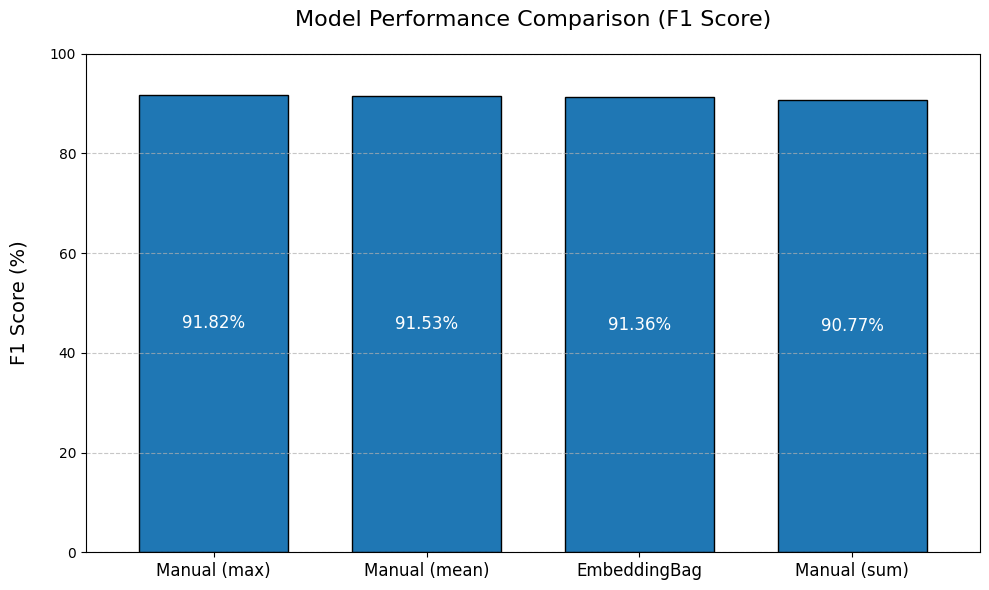

In [85]:
plot_and_select_best_model(all_trained_data)

### Prediction

In [51]:
test_products = [
    # --- Fruit-Focused Recipe Style ---
    'a bit sweeter  mango chutney',
    'apple a day  smoothie',
    'tastes like mounds bar    coconut strawberry bites',
    'freshly squeezed  orange juice',
    
    # --- Vegetable-Focused Recipe Style ---
    '412 broccoli casserole',
    'cream  of cauliflower soup  vegan',
    'how i got my family to eat spinach  spinach dip',
    'i can t believe it s low fat  creamy potato salad',
    'garlic  roasted brussels sprouts',
   
    
    # --- Tricky / Combined / Edge Case Recipes ---
    'tomato  basil pasta sauce',
    'zucchini mix  in tomato sauce',
    'avocado  toast with secret seasoning',
    'better than spaghetti  squash bake',
]

In [52]:
for product in test_products:
    category = predict_catgory(model_embag,
                   product,
                   vocab,
                   preprocss_text,
                   device)
    print(f"Product : {product}\nPredicted : {category}.")


Product : a bit sweeter  mango chutney
Predicted : Fruit Recipe.
Product : apple a day  smoothie
Predicted : Fruit Recipe.
Product : tastes like mounds bar    coconut strawberry bites
Predicted : Fruit Recipe.
Product : freshly squeezed  orange juice
Predicted : Fruit Recipe.
Product : 412 broccoli casserole
Predicted : Vegetable Recipe.
Product : cream  of cauliflower soup  vegan
Predicted : Vegetable Recipe.
Product : how i got my family to eat spinach  spinach dip
Predicted : Vegetable Recipe.
Product : i can t believe it s low fat  creamy potato salad
Predicted : Vegetable Recipe.
Product : garlic  roasted brussels sprouts
Predicted : Vegetable Recipe.
Product : tomato  basil pasta sauce
Predicted : Vegetable Recipe.
Product : zucchini mix  in tomato sauce
Predicted : Vegetable Recipe.
Product : avocado  toast with secret seasoning
Predicted : Vegetable Recipe.
Product : better than spaghetti  squash bake
Predicted : Vegetable Recipe.
